In [398]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,precision_recall_curve,average_precision_score,auc,classification_report,f1_score
from xgboost import XGBClassifier

In [399]:
df = pd.read_csv('data.xls')

In [400]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [401]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [402]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [403]:
df.drop(columns=['customerID'],inplace=True)

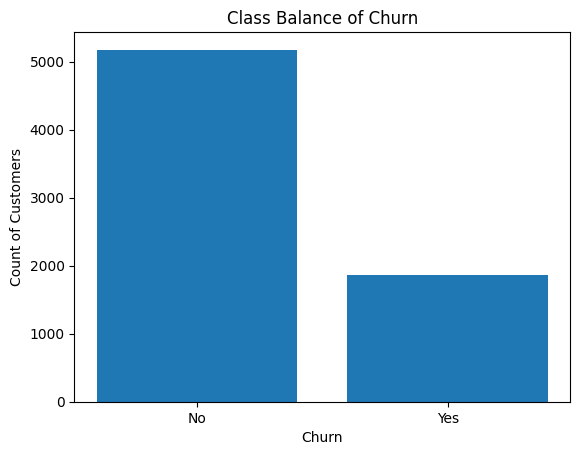

In [404]:

counts = df['Churn'].value_counts()

plt.bar(counts.index, counts.values)
plt.title("Class Balance of Churn")
plt.xlabel("Churn")
plt.ylabel("Count of Customers")
plt.show()


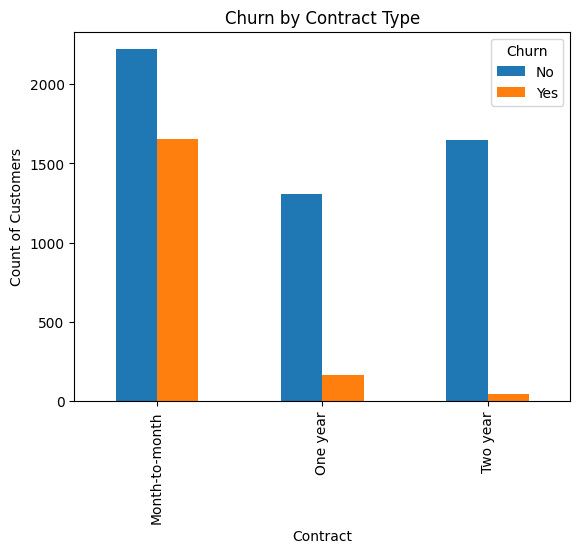

In [405]:
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()

contract_churn.plot(kind='bar')

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Count of Customers")
plt.show()


In [406]:
df['TotalCharges'].str.strip().eq("").sum()

np.int64(11)

In [407]:
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [408]:
catCols = df.select_dtypes(exclude=['int64','float64']).columns.tolist()
numCols = df.select_dtypes(include=['int64','float64']).columns.tolist()

In [409]:
for i in catCols:
  print(i,': ', df[i].unique())

gender :  ['Female' 'Male']
Partner :  ['Yes' 'No']
Dependents :  ['No' 'Yes']
PhoneService :  ['No' 'Yes']
MultipleLines :  ['No phone service' 'No' 'Yes']
InternetService :  ['DSL' 'Fiber optic' 'No']
OnlineSecurity :  ['No' 'Yes' 'No internet service']
OnlineBackup :  ['Yes' 'No' 'No internet service']
DeviceProtection :  ['No' 'Yes' 'No internet service']
TechSupport :  ['No' 'Yes' 'No internet service']
StreamingTV :  ['No' 'Yes' 'No internet service']
StreamingMovies :  ['No' 'Yes' 'No internet service']
Contract :  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling :  ['Yes' 'No']
PaymentMethod :  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn :  ['No' 'Yes']


In [410]:
df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)

In [411]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])

print(le.classes_)

['No' 'Yes']


In [412]:
X = df.drop(columns=['Churn'])
y = df['Churn']
catCols.remove('Churn')

In [413]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

encoder = OneHotEncoder(sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[catCols])
X_test_encoded = encoder.transform(X_test[catCols])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numCols])
X_test_scaled = scaler.transform(X_test[numCols])


In [414]:
model = LogisticRegression(class_weight='balanced')
X_train_final = np.hstack([X_train_encoded, X_train_scaled])
X_test_final = np.hstack([X_test_encoded, X_test_scaled])

model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:,1]

              precision    recall  f1-score   support

           0       0.99      0.26      0.41      1036
           1       0.32      0.99      0.49       373

    accuracy                           0.45      1409
   macro avg       0.66      0.62      0.45      1409
weighted avg       0.81      0.45      0.43      1409

Accuracy : 0.7502
Precision: 0.5176
Recall   : 0.8284
F1_score   : 0.6371


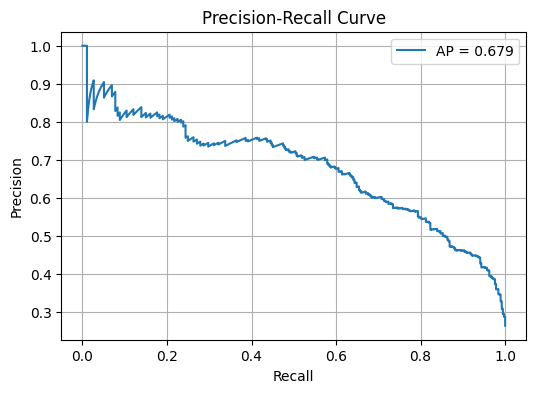

In [415]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
ap = average_precision_score(y_test, y_prob)

f1 = f1_score(y_test, y_pred)

print(classification_report(y_test, y_pred_b))

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1_score   : {f1:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
auc_score = auc(recalls, precisions)

plt.figure(figsize=(6,4))
plt.plot(recalls, precisions, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [416]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_b = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
model_b.fit(X_train_final, y_train)
y_prob_b = model_b.predict_proba(X_test_final)[:, 1]
y_pred_b = model_b.predict(X_test_final)

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1036
           1       0.56      0.70      0.62       373

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Precision: 0.5586
Recall: 0.7024
Average Precision: 0.6702
F1_score: 0.6223


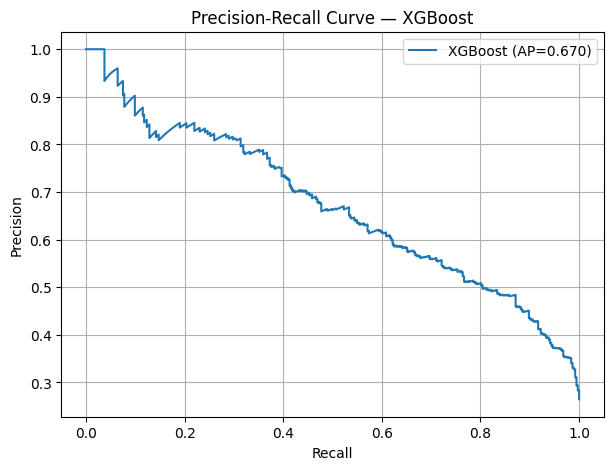

In [417]:
precision_b = precision_score(y_test, y_pred_b)
recall_b = recall_score(y_test, y_pred_b)
ap_b = average_precision_score(y_test, y_prob_b)
f1_b = f1_score(y_test, y_pred_b)

print(classification_report(y_test, y_pred_b))

print(f"Precision: {precision_b:.4f}")
print(f"Recall: {recall_b:.4f}")
print(f"Average Precision: {ap_b:.4f}")
print(f"F1_score: {f1_b:.4f}")

prec_b, rec_b, thr_b = precision_recall_curve(y_test, y_prob_b)

plt.figure(figsize=(7, 5))
plt.plot(rec_b, prec_b, label=f"XGBoost (AP={ap_b:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.legend()
plt.grid(True)
plt.savefig("pr_curve_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()

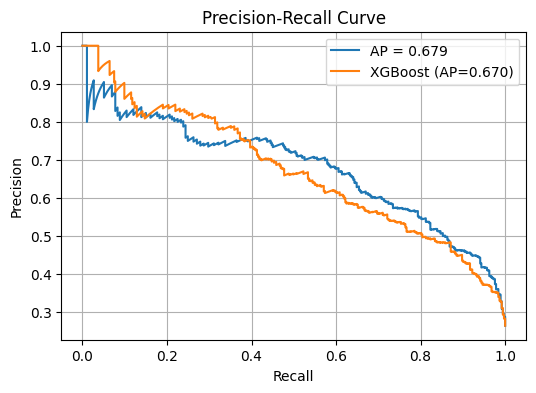

In [418]:
plt.figure(figsize=(6,4))
plt.plot(recalls, precisions, label=f"AP = {ap:.3f}")
plt.plot(rec_b, prec_b, label=f"XGBoost (AP={ap_b:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [419]:
threshold_grid = np.linspace(0.01, 0.99, 99)

def cost_at_threshold(y_test, y_prob, thresholds, call_cost=5, churn_cost=200):
    costs = []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        fp = ((y_hat == 1) & (y_test == 0)).sum()
        fn = ((y_hat == 0) & (y_test == 1)).sum()
        costs.append(fp * call_cost + fn * churn_cost)
    return np.array(costs)

costs_a = cost_at_threshold(y_test, y_prob, threshold_grid)
costs_b = cost_at_threshold(y_test, y_prob_b, threshold_grid)

best_t_a, best_cost_a = threshold_grid[costs_a.argmin()], costs_a.min()
best_t_b, best_cost_b = threshold_grid[costs_b.argmin()], costs_b.min()

print(f"LR:  threshold={best_t_a:.2f}, cost=${best_cost_a:,.0f}")
print(f"XGB: threshold={best_t_b:.2f}, cost=${best_cost_b:,.0f}")

LR:  threshold=0.10, cost=$4,310
XGB: threshold=0.01, cost=$4,445
